In [1]:
# imports... need to get data, transform it, graph, and add a custom image to the plot
import pandas as pd
import requests
import calendar
import matplotlib.image as mpimg
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

In [2]:
# where we're going to grab the data... requires a good amount of manipulation
url = 'https://www.hockey-reference.com/leagues/NHL_2026_games.html'
tables = pd.read_html(requests.get(url).text)

In [3]:
df = tables[0]

In [4]:
df.columns = [
    'game_date'
    ,'game_time'
    ,'team_away'
    ,'team_away_goals'
    ,'team_home'
    ,'team_home_goals'
    ,'game_ot'
    ,'game_attendance'
    ,'game_length'
    ,'game_notes'
]
df

,game_date,game_time,team_away,team_away_goals,team_home,team_home_goals,game_ot,game_attendance,game_length,game_notes
0,2025-10-07,5:00 PM,Chicago Blackhawks,2.0,Florida Panthers,3.0,NaN,19655.0,2:34,NaN
1,2025-10-07,10:30 PM,Colorado Avalanche,4.0,Los Angeles Kings,1.0,NaN,18145.0,2:37,NaN
2,2025-10-07,8:00 PM,Pittsburgh Penguins,3.0,New York Rangers,0.0,NaN,18006.0,2:16,NaN
3,2025-10-08,10:00 PM,Calgary Flames,4.0,Edmonton Oilers,3.0,SO,18347.0,2:55,NaN
4,2025-10-08,7:00 PM,Montreal Canadiens,2.0,Toronto Maple Leafs,5.0,NaN,19037.0,2:25,NaN
...,...,...,...,...,...,...,...,...,...,...
1307,2026-04-16,10:30 PM,Seattle Kraken,NaN,Colorado Avalanche,NaN,NaN,NaN,NaN,NaN
1308,2026-04-16,9:00 PM,Vancouver Canucks,NaN,Edmonton Oilers,NaN,NaN,NaN,NaN,NaN
1309,2026-04-16,8:00 PM,Anaheim Ducks,NaN,Nashville Predators,NaN,NaN,NaN,NaN,NaN
1310,2026-04-16,8:00 PM,St. Louis Blues,NaN,Utah Mammoth,NaN,NaN,NaN,NaN,NaN


In [5]:
# need to calculate points per game so we can track changein standings by month
def winning_team_test(team_a, score_a, team_b, score_b, ot_result):
    if score_a > score_b and pd.isna(ot_result) == False:
        return team_a, 2, team_b, 1
    elif score_a > score_b:
        return team_a, 2, team_b, 0
    elif score_b > score_a and pd.isna(ot_result) == False:
        return team_b, 2, team_a, 1
    elif score_b > score_a:
        return team_b, 2, team_a, 0

In [6]:
winning_team_test('sabres',3,'leafs',1,'OT')

('sabres', 2, 'leafs', 1)

In [7]:
# function to use on df
def winning_team(row):
    if row['team_away_goals'] > row['team_home_goals'] and pd.isna(row['game_ot']) == False:
        return row['team_away'], 2, row['team_home'], 1
    elif row['team_away_goals'] > row['team_home_goals']:
        return row['team_away'], 2, row['team_home'], 0
    elif row['team_home_goals'] > row['team_away_goals'] and pd.isna(row['game_ot']) == False:
        return row['team_home'], 2, row['team_away'], 1
    elif row['team_home_goals'] > row['team_away_goals']:
        return row['team_home'], 2, row['team_away'], 0
    else:
        return 'future_game', 0, 'future_game', 0

In [8]:
# add columns for team point math
df['game_winning_team'] = df.apply(lambda row: winning_team(row)[0], axis=1)
df['game_winning_points'] = df.apply(lambda row: winning_team(row)[1], axis=1)
df['game_losing_team'] = df.apply(lambda row: winning_team(row)[2], axis=1)
df['game_losing_points'] = df.apply(lambda row: winning_team(row)[3], axis=1)

In [9]:
df

,game_date,game_time,team_away,team_away_goals,team_home,team_home_goals,game_ot,game_attendance,game_length,game_notes,game_winning_team,game_winning_points,game_losing_team,game_losing_points
0,2025-10-07,5:00 PM,Chicago Blackhawks,2.0,Florida Panthers,3.0,NaN,19655.0,2:34,NaN,Florida Panthers,2,Chicago Blackhawks,0
1,2025-10-07,10:30 PM,Colorado Avalanche,4.0,Los Angeles Kings,1.0,NaN,18145.0,2:37,NaN,Colorado Avalanche,2,Los Angeles Kings,0
2,2025-10-07,8:00 PM,Pittsburgh Penguins,3.0,New York Rangers,0.0,NaN,18006.0,2:16,NaN,Pittsburgh Penguins,2,New York Rangers,0
3,2025-10-08,10:00 PM,Calgary Flames,4.0,Edmonton Oilers,3.0,SO,18347.0,2:55,NaN,Calgary Flames,2,Edmonton Oilers,1
4,2025-10-08,7:00 PM,Montreal Canadiens,2.0,Toronto Maple Leafs,5.0,NaN,19037.0,2:25,NaN,Toronto Maple Leafs,2,Montreal Canadiens,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,2026-04-16,10:30 PM,Seattle Kraken,NaN,Colorado Avalanche,NaN,NaN,NaN,NaN,NaN,future_game,0,future_game,0
1308,2026-04-16,9:00 PM,Vancouver Canucks,NaN,Edmonton Oilers,NaN,NaN,NaN,NaN,NaN,future_game,0,future_game,0
1309,2026-04-16,8:00 PM,Anaheim Ducks,NaN,Nashville Predators,NaN,NaN,NaN,NaN,NaN,future_game,0,future_game,0
1310,2026-04-16,8:00 PM,St. Louis Blues,NaN,Utah Mammoth,NaN,NaN,NaN,NaN,NaN,future_game,0,future_game,0


In [10]:
# create df for by game date point accumulation
df_winning_team = df[['game_date','game_winning_team', 'game_winning_points']]
df_winning_team.columns = ['game_date', 'team', 'points']

df_losing_team = df[['game_date','game_losing_team', 'game_losing_points']]
df_losing_team.columns = ['game_date', 'team', 'points']

In [11]:
df_team_game_results = pd.concat([df_winning_team, df_losing_team], ignore_index=True)

In [12]:
df_team_game_results

,game_date,team,points
0,2025-10-07,Florida Panthers,2
1,2025-10-07,Colorado Avalanche,2
2,2025-10-07,Pittsburgh Penguins,2
3,2025-10-08,Calgary Flames,2
4,2025-10-08,Toronto Maple Leafs,2
...,...,...,...
2619,2026-04-16,future_game,0
2620,2026-04-16,future_game,0
2621,2026-04-16,future_game,0
2622,2026-04-16,future_game,0


In [13]:
# atlantic division filter
atlantic_division = [
    'Buffalo Sabres'
    ,'Tampa Bay Lightning'
    ,'Montreal Canadiens'
    ,'Boston Bruins'
    ,'Detroit Red Wings'
    ,'Ottawa Senators'
    ,'Toronto Maple Leafs'
    ,'Florida Panthers'
]

In [14]:
df_atlantic_division = df_team_game_results[df_team_game_results['team'].isin(atlantic_division)].reset_index(drop=True)

In [15]:
df_atlantic_division

,game_date,team,points
0,2025-10-07,Florida Panthers,2
1,2025-10-08,Toronto Maple Leafs,2
2,2025-10-08,Boston Bruins,2
3,2025-10-09,Boston Bruins,2
4,2025-10-09,Montreal Canadiens,2
...,...,...,...
542,2026-03-17,Boston Bruins,1
543,2026-03-17,Toronto Maple Leafs,0
544,2026-03-17,Florida Panthers,0
545,2026-03-18,Ottawa Senators,0


In [16]:
# add columns for month by month tracking and sorting
month_abbr = dict(enumerate(calendar.month_abbr))
df_atlantic_division['month_num'] = df_atlantic_division['game_date'].str[5:7].astype(int)
df_atlantic_division['month_num_sort'] = df_atlantic_division['game_date'].str[:4] + '-' + df_atlantic_division['game_date'].str[5:7]
df_atlantic_division['month'] = df_atlantic_division['month_num'].map(month_abbr)
df_atlantic_division

,game_date,team,points,month_num,month_num_sort,month
0,2025-10-07,Florida Panthers,2,10,2025-10,Oct
1,2025-10-08,Toronto Maple Leafs,2,10,2025-10,Oct
2,2025-10-08,Boston Bruins,2,10,2025-10,Oct
3,2025-10-09,Boston Bruins,2,10,2025-10,Oct
4,2025-10-09,Montreal Canadiens,2,10,2025-10,Oct
...,...,...,...,...,...,...
542,2026-03-17,Boston Bruins,1,3,2026-03,Mar
543,2026-03-17,Toronto Maple Leafs,0,3,2026-03,Mar
544,2026-03-17,Florida Panthers,0,3,2026-03,Mar
545,2026-03-18,Ottawa Senators,0,3,2026-03,Mar


In [17]:
# calculate points per month
df_points_by_month = df_atlantic_division.groupby(['team', 'month', 'month_num', 'month_num_sort'], as_index=False).agg(
    month_points=('points','sum')
).sort_values(by='month_num_sort').reset_index(drop=True)

In [18]:
# calculate where points per month ranks month over month...
df_points_by_month['running_points'] = df_points_by_month.groupby('team')['month_points'].cumsum()
df_points_by_month['standing_by_month'] = df_points_by_month.groupby('month_num_sort')['running_points'].rank(method='dense', ascending=False).astype(int)
df_points_by_month

,team,month,month_num,month_num_sort,month_points,running_points,standing_by_month
0,Florida Panthers,Oct,10,2025-10,11,11,4
1,Tampa Bay Lightning,Oct,10,2025-10,12,12,3
2,Ottawa Senators,Oct,10,2025-10,13,13,2
3,Montreal Canadiens,Oct,10,2025-10,16,16,1
4,Detroit Red Wings,Oct,10,2025-10,16,16,1
5,Buffalo Sabres,Oct,10,2025-10,11,11,4
6,Toronto Maple Leafs,Oct,10,2025-10,11,11,4
7,Boston Bruins,Oct,10,2025-10,12,12,3
8,Ottawa Senators,Nov,11,2025-11,15,28,4
9,Buffalo Sabres,Nov,11,2025-11,13,24,6


In [19]:
# line colors
def assign_colors(row):
    if row['team'] == 'Toronto Maple Leafs':
        return '#BBCDF0'
    elif row['team'] == 'Ottawa Senators':
        return '#FACAF8'
    elif row['team'] == 'Tampa Bay Lightning':
        return '#DBD5D5'
    elif row['team'] == 'Florida Panthers':
        return '#DFC3F7'
    elif row['team'] == 'Detroit Red Wings':
        return '#F78895'
    elif row['team'] == 'Boston Bruins':
        return '#FCDC95'
    elif row['team'] == 'Montreal Canadiens':
        return '#C1F5E0'
    elif row['team'] == 'Buffalo Sabres':
        return '#000000'
    else:
        return '#E62727'

In [20]:
def assign_colors_plt(team):
    if team == 'Toronto Maple Leafs':
        return '#BBCDF0'
    elif team == 'Ottawa Senators':
        return '#FACAF8'
    elif team == 'Tampa Bay Lightning':
        return '#DBD5D5'
    elif team == 'Florida Panthers':
        return '#DFC3F7'
    elif team == 'Detroit Red Wings':
        return '#F78895'
    elif team == 'Boston Bruins':
        return '#FCDC95'
    elif team == 'Montreal Canadiens':
        return '#C1F5E0'
    elif team == 'Buffalo Sabres':
        return '#000000'
    else:
        return '#E62727'

In [21]:
# pivot to use custom plotly... using instead of bumplot for versioning reasons
df_rank_pivot = df_points_by_month.pivot(index='month_num_sort',
                                         columns=['team'],
                                         values='standing_by_month')

In [22]:
# resize sabres logo so it fits on plot
img_local_path = r'C:\Users\nickp\OneDrive\Desktop\Home Data Projects\Viz\mtb-viz-challenge\Bump chart\\'
img_local_file_name = r'goathead.png'
img = Image.open(img_local_path+img_local_file_name)
width, height = img.size
print(f"Width {width}; Height {height}")
# Define the new width and calculate the new height to maintain the aspect ratio
new_width = 50
new_height = int(height * (new_width / width))

# Resize the image using the LANCZOS filter for high quality downsampling
resized_img = img.resize((new_width, new_height), Image.LANCZOS) #

# Save the new image
img_new_file_name = r'goathead_smaller.png'
resized_img.save(img_local_path+img_new_file_name)

Width 905; Height 785


In [23]:
# transform image and add coordinates so it can be used on plot
goathead = mpimg.imread(img_local_path+img_new_file_name)
imagebox = OffsetImage(goathead)

df_sabres = df_points_by_month[df_points_by_month['team']== 'Buffalo Sabres']
df_sabres

,team,month,month_num,month_num_sort,month_points,running_points,standing_by_month
5,Buffalo Sabres,Oct,10,2025-10,11,11,4
9,Buffalo Sabres,Nov,11,2025-11,13,24,6
18,Buffalo Sabres,Dec,12,2025-12,22,46,4
28,Buffalo Sabres,Jan,1,2026-01,21,67,4
35,Buffalo Sabres,Feb,2,2026-02,9,76,2
44,Buffalo Sabres,Mar,3,2026-03,16,92,1


<function matplotlib.pyplot.show(close=None, block=None)>

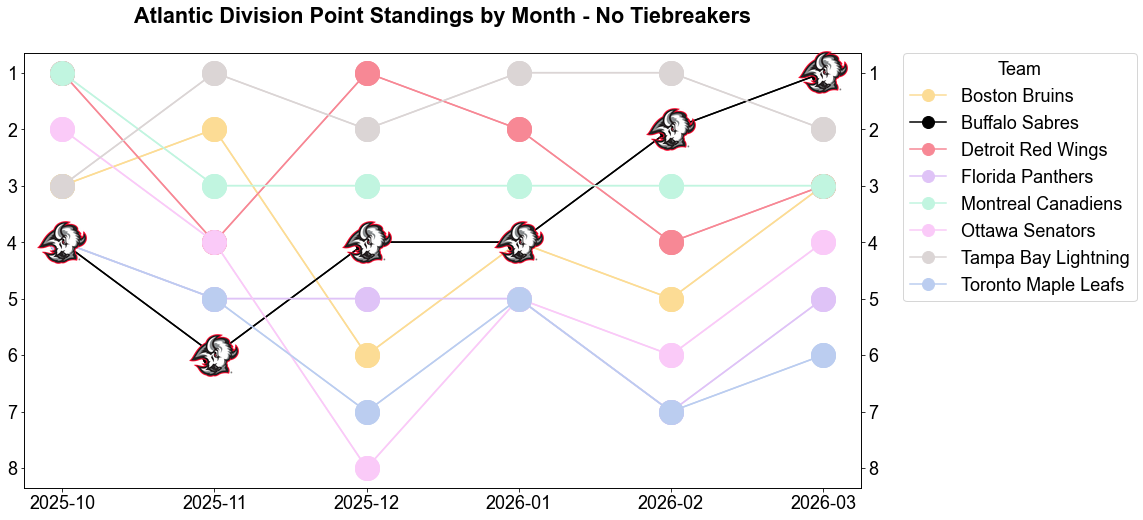

In [24]:
# build plot
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 18
mpl.rcParams['lines.markersize'] = 24
fig, ax1 = plt.subplots(figsize=(15, 8))
ax2 = ax1.twinx()

for column in df_rank_pivot.columns:
    ax1.plot(df_rank_pivot.index, df_rank_pivot[column], marker='o',color=assign_colors_plt(column), label=column)
    ax2.plot(df_rank_pivot.index, df_rank_pivot[column], marker='o',color=assign_colors_plt(column), label=column)

x = df_sabres['month_num_sort'].tolist()
y = df_sabres['standing_by_month'].tolist()
for x0, y0 in zip(x, y):
    # Create a NEW AnnotationBbox for each iteration
    ab = AnnotationBbox(imagebox, (x0, y0), frameon=False, xycoords='data') # Added xycoords for clarity
    ax2.add_artist(ab)

fig.set_facecolor('white')
ax1.invert_yaxis() # Invert the Y-axis
ax2.invert_yaxis() # Invert the Y-axis
ax1.legend(title='Team', markerscale=.5, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax1.set_title('Atlantic Division Point Standings by Month - No Tiebreakers', fontweight='bold', pad=30)

viz_name = r'Sabres Ascension.png'
fig.savefig(img_local_path+viz_name, bbox_inches='tight')
plt.show